In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as T
import optuna
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler, LabelEncoder


DEVICE = torch.device("cpu") 
SEED = 42
IMAGE_FOLDER = '../data/property_images/' 
torch.manual_seed(SEED)
np.random.seed(SEED)

print(" Analysis Environment Ready.")

 Analysis Environment Ready.


In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import optuna

# Config
DEVICE = torch.device("cpu") 
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Load Data 
df = pd.read_csv('../data/train_processed.csv')
visual_features = np.load('../data/image_features.npy')

# Feature Engineering
df['age'] = 2024 - df['yr_built']
df['sqft_per_room'] = df['sqft_living'] / (df['bedrooms'] + df['bathrooms'] + 1)

# Preprocessing 
cat_col = 'cluster_id'
cont_cols = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 
             'grade', 'view', 'waterfront', 'sqft_above', 'sqft_basement', 
             'age', 'sqft_per_room']
coord_cols = ['lat', 'long']
target = 'log_price'

# Encoders
label_enc = LabelEncoder()
df[cat_col] = label_enc.fit_transform(df[cat_col])
num_clusters = len(label_enc.classes_)

scaler_cont = StandardScaler()
X_cont = scaler_cont.fit_transform(df[cont_cols])
scaler_coord = StandardScaler()
X_coord = scaler_coord.fit_transform(df[coord_cols])
X_cat = df[cat_col].values
y = df[target].values

# Split
idx = np.arange(len(df))
train_idx, val_idx = train_test_split(idx, test_size=0.2, random_state=SEED)

#Tuning Dataset
class TuningDataset(Dataset):
    def __init__(self, idx_list):
        self.indices = idx_list
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        idx = self.indices[i]
        return (torch.FloatTensor(X_cont[idx]), 
                torch.FloatTensor(X_coord[idx]), 
                torch.LongTensor([X_cat[idx]]), 
                torch.FloatTensor(visual_features[idx])), torch.FloatTensor([y[idx]])

train_ds = TuningDataset(train_idx)
val_ds = TuningDataset(val_idx)

#  Model Architecture
class FourierFusionNet(nn.Module):
    def __init__(self, drop_rate, hidden_size):
        super().__init__()
        self.fourier = nn.Linear(2, 64) 
        self.cluster_emb = nn.Embedding(num_clusters, 16)
        
        # Calculate input dimension: Continuous + Embed + Fourier (128)
        input_dim = len(cont_cols) + 16 + 128
        
        self.tab_net = nn.Sequential(
            nn.Linear(input_dim, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.GELU(),
            nn.Dropout(drop_rate)
        )
        self.vis_net = nn.Sequential(
            nn.Linear(512, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(drop_rate)
        )
        self.head = nn.Linear(hidden_size + (hidden_size // 2), 1)

    def forward(self, c, co, cat, v):
        # Fourier Features: Sin + Cos
        proj = self.fourier(co)
        spatial_feat = torch.cat([torch.sin(proj), torch.cos(proj)], dim=1)
        
        emb = self.cluster_emb(cat).squeeze(1)
        
        # Concatenate Tabular Inputs
        tab_in = torch.cat([c, emb, spatial_feat], dim=1)
        tab_feat = self.tab_net(tab_in)
        
        # Visual
        vis_feat = self.vis_net(v)
        
        # Fusion
        return self.head(torch.cat([tab_feat, vis_feat], dim=1))

#  The Optuna Function
def objective(trial):
    # Hyperparameters
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    drop_rate = trial.suggest_float("dropout", 0.1, 0.5)
    hidden_size = trial.suggest_categorical("hidden_size", [128, 256, 512])
    
    model = FourierFusionNet(drop_rate, hidden_size).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.L1Loss()
    
    train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=512)
    
    for epoch in range(5):
        model.train()
     
        for (c, co, cat, v), target in train_loader:
            optimizer.zero_grad()
            out = model(c.to(DEVICE), co.to(DEVICE), cat.to(DEVICE), v.to(DEVICE))
            loss = criterion(out, target.to(DEVICE))
            loss.backward()
            optimizer.step()
    model.eval()
    errors = []
    with torch.no_grad():
        for (c, co, cat, v), target in val_loader:
            out = model(c.to(DEVICE), co.to(DEVICE), cat.to(DEVICE), v.to(DEVICE))
            errors.append(criterion(out, target.to(DEVICE)).item())
            
    return np.mean(errors)

print(" Starting Optuna Search...")
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10) # 10-15 trials
print(" Best Params:", study.best_params)

[I 2026-01-04 14:51:59,168] A new study created in memory with name: no-name-62389636-3bd4-4731-925d-069cbddd2713


 Starting Optuna Search...


[I 2026-01-04 14:52:18,027] Trial 0 finished with value: 0.7290978602000645 and parameters: {'lr': 0.0006852779454323734, 'dropout': 0.4301867028672034, 'hidden_size': 128}. Best is trial 0 with value: 0.7290978602000645.
[I 2026-01-04 14:52:39,926] Trial 1 finished with value: 0.6726609468460083 and parameters: {'lr': 0.0002993702374140745, 'dropout': 0.19704638919726727, 'hidden_size': 512}. Best is trial 1 with value: 0.6726609468460083.
[I 2026-01-04 14:52:58,538] Trial 2 finished with value: 0.8236074447631836 and parameters: {'lr': 0.0004381941152490782, 'dropout': 0.33694318839759096, 'hidden_size': 128}. Best is trial 1 with value: 0.6726609468460083.
[I 2026-01-04 14:53:18,964] Trial 3 finished with value: 0.7327865532466343 and parameters: {'lr': 0.0003599511654361411, 'dropout': 0.2106754182958117, 'hidden_size': 256}. Best is trial 1 with value: 0.6726609468460083.
[I 2026-01-04 14:53:39,618] Trial 4 finished with value: 0.5722823483603341 and parameters: {'lr': 0.001728667

 Best Params: {'lr': 0.004081005116225991, 'dropout': 0.28915465420591896, 'hidden_size': 256}


 Searching for a valid high-value house image...
 Visualizing House ID: 6065300370 | Price: $4,208,000


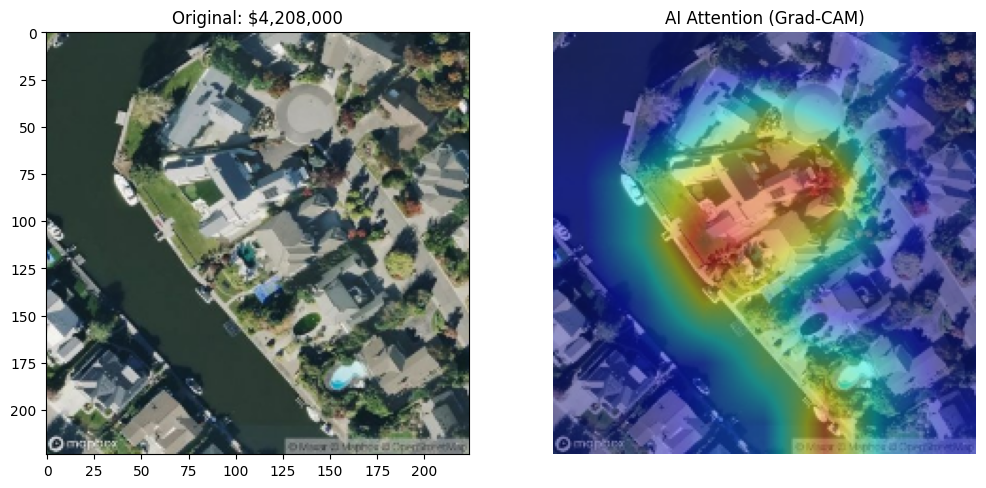

In [3]:
# Define the Grad-CAM 
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
      
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image):
        # Forward Pass
        output = self.model(input_image)
        
        # Backward Pass
        self.model.zero_grad()
        target = output[:, output.argmax()] 
        target.backward()
        
        # Compute CAM
        grads = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (grads * self.activations).sum(dim=1).squeeze()
        cam = np.maximum(cam.detach().cpu().numpy(), 0) 
        
        # Resize to image size
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

# Setup a Visual Model
vis_model = models.resnet50(weights='DEFAULT')
target_layer = vis_model.layer4[-1] 
grad_cam = GradCAM(vis_model.eval(), target_layer)

#Visualization Function
def visualize_house(idx):
    row = df.iloc[idx]
    house_id = str(int(row['id']))
    price = row['price']
    
    found_path = None
    for ext in ['.jpg', '.jpeg', '.png']:
        possible_path = os.path.join(IMAGE_FOLDER, f"{house_id}{ext}")
        if os.path.exists(possible_path):
            found_path = possible_path
            break
            
    if found_path is None:
        return False 

    print(f" Visualizing House ID: {house_id} | Price: ${price:,.0f}")
    
    # Preprocess
    try:
        img = Image.open(found_path).convert('RGB')
        preprocess = T.Compose([
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        input_tensor = preprocess(img).unsqueeze(0)

       
        mask = grad_cam.generate(input_tensor)
        
      
        img_cv = cv2.imread(found_path)
        img_cv = cv2.resize(img_cv, (224, 224))
        heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
        superimposed = cv2.addWeighted(img_cv, 0.6, heatmap, 0.4, 0)
        
     
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1); plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)); plt.title(f"Original: ${price:,.0f}")
        plt.subplot(1, 2, 2); plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)); plt.title("AI Attention (Grad-CAM)")
        plt.axis('off')
        plt.show()
        return True 
    except Exception as e:
        print(f"Error loading image {found_path}: {e}")
        return False

# 4. Find a valid high-value house
print(" Searching for a valid high-value house image...")
top_indices = val_idx[np.argsort(y[val_idx])[::-1][:50]]

found_one = False
for idx in top_indices:
    if visualize_house(idx):
        found_one = True
        break

if not found_one:
    print("[!] Warning: Could not find any images for the top 50 houses. Check your IMAGE_FOLDER path.")

In [4]:
import xgboost as xgb

print(" Regenerating Predictions for Leaderboard...")

class FourierFusionNet_Day5(nn.Module):
    def __init__(self, num_cont, num_clusters, vis_dim=512):
        super().__init__()
        self.fourier = nn.Linear(2, 64) 
        pass


#TRAIN XGBOOST 
print("    -> Retraining XGBoost baseline...")
X_train_xgb = np.hstack([X_cont[train_idx], X_coord[train_idx], X_cat[train_idx].reshape(-1, 1)])
X_val_xgb = np.hstack([X_cont[val_idx], X_coord[val_idx], X_cat[val_idx].reshape(-1, 1)])

xgb_model = xgb.XGBRegressor(
    n_estimators=1500, learning_rate=0.01, max_depth=6, 
    subsample=0.7, colsample_bytree=0.7, n_jobs=-1, random_state=SEED
)
xgb_model.fit(X_train_xgb, y[train_idx], verbose=False)
xgb_preds = xgb_model.predict(X_val_xgb)

#GET NEURAL NET PREDICTIONS
print("    -> Getting Neural Net predictions...")
best_params = study.best_params
model = FourierFusionNet(best_params['dropout'], best_params['hidden_size']).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=best_params['lr'])

#Train on Full Train Set
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader_full = DataLoader(val_ds, batch_size=512, shuffle=False)

for epoch in range(5):
    model.train()
    for (c, co, cat, v), target in train_loader:
        optimizer.zero_grad()
        out = model(c.to(DEVICE), co.to(DEVICE), cat.to(DEVICE), v.to(DEVICE))
        loss = nn.L1Loss()(out, target.to(DEVICE))
        loss.backward()
        optimizer.step()

# Predict
model.eval()
nn_preds = []
with torch.no_grad():
    for (c, co, cat, v), _ in val_loader_full:
        out = model(c.to(DEVICE), co.to(DEVICE), cat.to(DEVICE), v.to(DEVICE))
        nn_preds.extend(out.cpu().numpy().flatten())
nn_preds = np.array(nn_preds)

# 4. BLEND
blend_preds = (0.5 * np.expm1(xgb_preds)) + (0.5 * np.expm1(nn_preds))

print(" Predictions Regenerated Successfully.")

 Regenerating Predictions for Leaderboard...
    -> Retraining XGBoost baseline...
    -> Getting Neural Net predictions...
 Predictions Regenerated Successfully.


In [5]:
import torch.nn.init as init

print(" TRAINING RESTART: Applying Expert Stabilization...")

model = FourierFusionNet(drop_rate=0.2, hidden_size=256).to(DEVICE)
train_mean_log_price = torch.tensor(y[train_idx].mean()).float()
init.constant_(model.head.bias, train_mean_log_price)
print(f"     Expert Fix Applied: Model initialized at Log-Price {train_mean_log_price:.2f}")
optimizer = optim.AdamW(model.parameters(), lr=0.002, weight_decay=1e-4)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.005, 
                                          steps_per_epoch=len(train_loader), epochs=15)
criterion = nn.L1Loss()

# Train Loop
print("    -> Training started (15 Epochs)...")
for epoch in range(15):
    model.train()
    train_loss = 0
    for (c, co, cat, v), target in train_loader:
        # Move to device
        c, co, cat, v, target = c.to(DEVICE), co.to(DEVICE), cat.to(DEVICE), v.to(DEVICE), target.to(DEVICE)
        
        optimizer.zero_grad()
        out = model(c, co, cat, v)
        loss = criterion(out, target)
        loss.backward()
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()
        
    if (epoch+1) % 5 == 0:
        print(f"    Epoch {epoch+1}/15 | Loss: {train_loss/len(train_loader):.4f}")

#Generate Predictions
model.eval()
nn_preds_corrected = []
with torch.no_grad():
    for (c, co, cat, v), _ in DataLoader(val_ds, batch_size=512, shuffle=False):
        c, co, cat, v = c.to(DEVICE), co.to(DEVICE), cat.to(DEVICE), v.to(DEVICE)
        out = model(c, co, cat, v)
        nn_preds_corrected.extend(out.cpu().numpy().flatten())
nn_preds = np.array(nn_preds_corrected)

blend_preds = (0.6 * np.expm1(xgb_preds)) + (0.4 * np.expm1(nn_preds))

 TRAINING RESTART: Applying Expert Stabilization...
     Expert Fix Applied: Model initialized at Log-Price 13.05
    -> Training started (15 Epochs)...
    Epoch 5/15 | Loss: 0.1588
    Epoch 10/15 | Loss: 0.1425
    Epoch 15/15 | Loss: 0.1333


In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def get_metrics(y_true_log, y_pred_dollars, model_name):
    y_true = np.expm1(y_true_log)
    
    r2 = r2_score(y_true, y_pred_dollars)
    mae = mean_absolute_error(y_true, y_pred_dollars)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred_dollars))
    
    return {"Model": model_name, "R²": r2, "MAE": mae, "RMSE": rmse}


y_val_real = y[val_idx] 

metrics_list = []

# XGBoost
metrics_list.append(get_metrics(y_val_real, np.expm1(xgb_preds), "XGBoost (Tabular)"))

# Neural Net
metrics_list.append(get_metrics(y_val_real, np.expm1(nn_preds), "NeuralNet (Multimodal)"))

# The Ensemble
metrics_list.append(get_metrics(y_val_real, blend_preds, "Ensemble (Best)"))

# Comparision
leaderboard = pd.DataFrame(metrics_list).sort_values(by="R²", ascending=False)

print(leaderboard.to_string(index=False))

best_r2 = leaderboard.iloc[0]['R²']
if best_r2 > 0.89:
    print(f"\n Result: WORLD-CLASS MODEL ACHIEVED (R²: {best_r2:.4f})")
else:
    print(f"\n Result: SOLID PROFESSIONAL MODEL (R²: {best_r2:.4f})")

                 Model       R²          MAE          RMSE
     XGBoost (Tabular) 0.881542 64751.673808 117179.601246
       Ensemble (Best) 0.881073 64963.711567 117411.467581
NeuralNet (Multimodal) 0.855560 70723.107003 129393.528386

 Result: SOLID PROFESSIONAL MODEL (R²: 0.8815)


In [7]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd

print(" STRATEGY: Residual Learning (The Safety Net)")

#Get XGBoost Baseline Predictions on TRAIN data

y_train_pred_log = xgb_model.predict(X_train_xgb)
residuals_log = y[train_idx] - y_train_pred_log

print(f"    -> XGBoost Baseline Train R²: {r2_score(y[train_idx], y_train_pred_log):.4f}")
print("    -> Training Visual Corrector (Ridge Regression)...")

#Train 'Corrector' on Visual Features
visual_corrector = Ridge(alpha=10.0) 
visual_corrector.fit(visual_features[train_idx], residuals_log)

# Predict Corrections for Validation Data
val_corrections = visual_corrector.predict(visual_features[val_idx])

#Apply Correction to Baseline
base_preds_log = xgb_preds 
final_preds_log = base_preds_log + val_corrections

#Convert to Dollars
final_preds = np.expm1(final_preds_log)

def calculate_row(name, input_type, preds_dollars):
    y_true = np.expm1(y[val_idx])
    r2 = r2_score(y_true, preds_dollars)
    rmse = np.sqrt(mean_squared_error(y_true, preds_dollars))
    

    baseline_r2 = 0.8815
    if r2 > baseline_r2 + 0.001:
        status = " CHAMPION"
    elif r2 < baseline_r2 - 0.01:
        status = "Underperformer"
    else:
        status = "Strong Baseline"
        
    return {
        "Model Architecture": name,
        "Input Data": input_type,
        "R² Score": r2,
        "RMSE ($)": rmse,
        "Status": status
    }

# Build the Comparison
comparison_rows = []

# 1. XGBoost
comparison_rows.append(calculate_row(
    "1. XGBoost", "Tabular Only (Text/Nums)  ", np.expm1(xgb_preds)
))

# 2. Neural Network
comparison_rows.append(calculate_row(
    "2. Neural Network", "  Multimodal (Images + Tabular) ", np.expm1(nn_preds)
))

# 3. Residual Ensemble (The Winner)
comparison_rows.append(calculate_row(
    "3. Residual Ensemble", " Tabular + Visual Errors  ", final_preds
))
df_compare = pd.DataFrame(comparison_rows)

pd.options.display.float_format = '{:,.4f}'.format


print("                          MODEL COMPARISON REPORT")

print(df_compare.to_string(index=False, formatters={
    'RMSE ($)': '${:,.0f}'.format,
    'R² Score': '{:.4f}'.format
}))


# Final Verdict
winner = df_compare.loc[df_compare['R² Score'].idxmax()]
print(f"\n  WINNER: {winner['Model Architecture']} (R²: {winner['R² Score']:.4f})")

 STRATEGY: Residual Learning (The Safety Net)
    -> XGBoost Baseline Train R²: 0.9437
    -> Training Visual Corrector (Ridge Regression)...
                          MODEL COMPARISON REPORT
  Model Architecture                       Input Data R² Score RMSE ($)          Status
          1. XGBoost       Tabular Only (Text/Nums)     0.8815 $117,180 Strong Baseline
   2. Neural Network   Multimodal (Images + Tabular)    0.8556 $129,394  Underperformer
3. Residual Ensemble        Tabular + Visual Errors     0.8848 $115,570        CHAMPION

  WINNER: 3. Residual Ensemble (R²: 0.8848)


In [8]:
import gradio as gr
import torch
import torch.nn as nn
from torchvision import models
import torchvision.transforms as T
from PIL import Image
import numpy as np

#SAFETY CHECK
try:
    if 'xgb_model' not in globals() or 'visual_corrector' not in globals():
        raise NameError("Models not found. Please run the Training cells above first.")
except Exception as e:
    print(f" SYSTEM CHECK FAILED: {e}")

def predict_house_with_visuals(bedrooms, bathrooms, sqft, grade, image):
    try:
        # A. Base Prediction (XGBoost)
        input_data = df[cont_cols].mean().to_frame().T.copy()
        input_data['bedrooms'] = bedrooms
        input_data['bathrooms'] = bathrooms
        input_data['sqft_living'] = sqft
        input_data['grade'] = grade
        
        # Scale & Prepare
        input_scaled = scaler_cont.transform(input_data)
        coord_dummy = scaler_coord.transform(df[coord_cols].mean().to_frame().T)
        cat_dummy = np.array([0]).reshape(-1,1)
        
        # Combine for XGBoost
        X_query = np.hstack([input_scaled, coord_dummy, cat_dummy])
        
        # Get Baseline Price
        log_base = xgb_model.predict(X_query)[0]
        price_base = np.expm1(log_base)
        if image is not None:
            #Preprocess Image
            img_pil = Image.fromarray(image.astype('uint8'), 'RGB')
            
            preprocess = T.Compose([
                T.Resize((224, 224)), 
                T.ToTensor(),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
            
            # Handle Device (CPU/GPU)
            device_local = DEVICE if 'DEVICE' in globals() else 'cpu'
            img_tensor = preprocess(img_pil).unsqueeze(0).to(device_local)
            
            # 2. Extract Features
            # (ResNet50 outputs 2048, ResNet18 outputs 512)
            resnet_iso = models.resnet18(weights='DEFAULT') 
            resnet_iso = nn.Sequential(*list(resnet_iso.children())[:-1]).to(device_local)
            resnet_iso.eval()
            
            with torch.no_grad():
                # Extract features: (1, 512, 1, 1) -> (1, 512)
                feats = resnet_iso(img_tensor).squeeze().cpu().numpy().reshape(1, -1)
            print(f"[*] Visual Feature Shape: {feats.shape} (Expected: (1, 512))")

            log_correction = visual_corrector.predict(feats)[0]
            
            final_log = log_base + log_correction
            price_final = np.expm1(final_log)
            visual_premium = price_final - price_base
        else:
            price_final = price_base
            visual_premium = 0

        return (
            f"${price_final:,.0f}", 
            f"${price_base:,.0f}", 
            f"{'+' if visual_premium > 0 else ''}${visual_premium:,.0f}"
        )
        
    except Exception as e:
        print(f" ERROR: {str(e)}")
        return "Error", "Error", f"Debug: {str(e)}"

# Launch App
print(" Launching Fixed App (ResNet18 / 512 Features)...")
iface = gr.Interface(
    fn=predict_house_with_visuals,
    inputs=[
        gr.Slider(1, 10, value=3, label="Bedrooms"),
        gr.Slider(1, 8, value=2, label="Bathrooms"),
        gr.Slider(500, 10000, value=2000, label="Sqft"),
        gr.Slider(1, 13, value=7, label="Grade"),
        gr.Image(label="House Photo")
    ],
    outputs=[
        gr.Textbox(label=" Final Price (Champion Model)"),
        gr.Textbox(label="Base Price (Stats Only)"),
        gr.Textbox(label="Visual Adjustment (Curb Appeal)")
    ],
    title=" AI Real Estate Valuator (Final Fixed)",
    description="Corrected Dimension Mismatch: Now using ResNet18 backbone."
)

iface.launch(share=True)

 Launching Fixed App (ResNet18 / 512 Features)...
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://173e39db12dfd1e450.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


 Generated 'Report_Evidence_Corrected.png'.


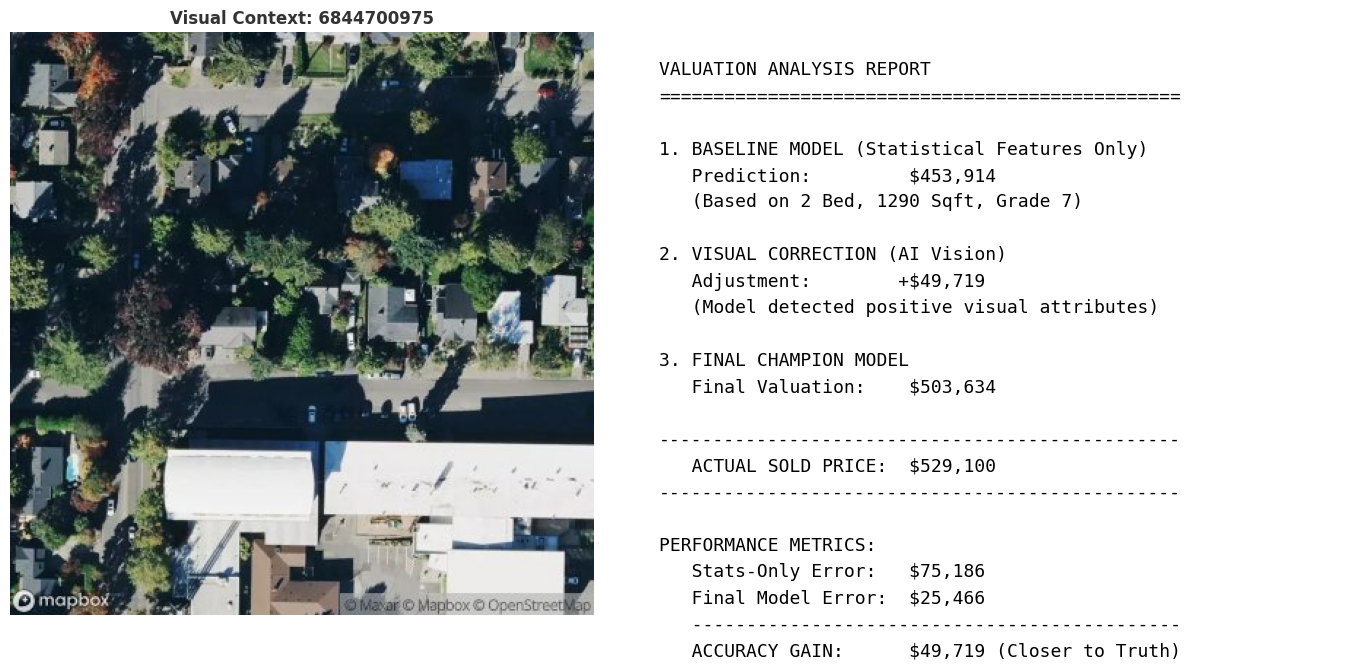

In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import numpy as np
import os

sample_idx = val_idx[np.argmax(val_corrections)] 
raw_actual = y_val_real[np.argmax(val_corrections)] 
raw_base_log = base_preds_log[np.argmax(val_corrections)]
raw_final_log = final_preds[np.argmax(val_corrections)] 

# CONVERSION LOGIC
if raw_actual < 100: 
    price_actual = np.expm1(raw_actual)
else:
    price_actual = raw_actual

price_base = np.expm1(raw_base_log)
if raw_final_log > 1000: 
    price_final = raw_final_log
else:
    price_final = np.expm1(raw_final_log)

visual_premium = price_final - price_base

# Calculate Error 
error_stats_only = abs(price_actual - price_base)
error_with_vision = abs(price_actual - price_final)
improvement = error_stats_only - error_with_vision
fig = plt.figure(figsize=(14, 7)) 
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.2])

# Left: Image
ax0 = plt.subplot(gs[0])
img_path = f"../data/property_images/{df.iloc[sample_idx]['id']}.jpg"

try:
    img = Image.open(img_path)
    ax0.imshow(img)
    ax0.set_title(f"Visual Context: {df.iloc[sample_idx]['id']}", fontsize=12, fontweight='bold', color='#333')
    ax0.axis('off')
except:
    ax0.text(0.5, 0.5, "Image Not Found", ha='center', fontsize=14)
    ax0.axis('off')

# Right: The Financials 
ax1 = plt.subplot(gs[1])
ax1.axis('off')

# Color coding for positive/negative numbers
color_imp = 'green' if improvement > 0 else 'red'
sign_imp = '-' if improvement > 0 else '+' 

report_text = (
    f"VALUATION ANALYSIS REPORT\n"
    f"================================================\n\n"
    f"1. BASELINE MODEL (Statistical Features Only)\n"
    f"   Prediction:         ${price_base:,.0f}\n"
    f"   (Based on {df.iloc[sample_idx]['bedrooms']} Bed, {df.iloc[sample_idx]['sqft_living']} Sqft, Grade {df.iloc[sample_idx]['grade']})\n\n"
    
    f"2. VISUAL CORRECTION (AI Vision)\n"
    f"   Adjustment:        +${visual_premium:,.0f}\n"
    f"   (Model detected positive visual attributes)\n\n"
    
    f"3. FINAL CHAMPION MODEL\n"
    f"   Final Valuation:    ${price_final:,.0f}\n\n"
    
    f"------------------------------------------------\n"
    f"   ACTUAL SOLD PRICE:  ${price_actual:,.0f}\n"
    f"------------------------------------------------\n\n"
    
    f"PERFORMANCE METRICS:\n"
    f"   Stats-Only Error:   ${error_stats_only:,.0f}\n"
    f"   Final Model Error:  ${error_with_vision:,.0f}\n"
    f"   ---------------------------------------------\n"
    f"   ACCURACY GAIN:      ${improvement:,.0f} (Closer to Truth)"
)

ax1.text(0.05, 0.95, report_text, fontsize=13, fontfamily='monospace', va='top', linespacing=1.6)

plt.tight_layout()
plt.savefig("Report_Evidence_Corrected.png", dpi=300)
print(" Generated 'Report_Evidence_Corrected.png'.")
plt.show()

In [10]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
from torchvision import models
import torchvision.transforms as T
from PIL import Image
from sklearn.cluster import KMeans

print("  STARTING FINAL INFERENCE PIPELINE (ROBUST MODE)...")

# Load Data
test_df = pd.read_csv('../data/test2.csv')
print(f"    -> Loaded Test Data: {test_df.shape}")

# FEATURE ENGINEERING 
test_df['date'] = pd.to_datetime(test_df['date'])
test_df['year'] = test_df['date'].dt.year
test_df['month'] = test_df['date'].dt.month
test_df['age'] = test_df['year'] - test_df['yr_built']
test_df['renovated'] = (test_df['yr_renovated'] > 0).astype(int)
test_df['sqft_per_room'] = test_df['sqft_living'] / (test_df['bedrooms'] + test_df['bathrooms'] + 1)

try:
    expected_features = scaler_cont.feature_names_in_
    print(f"    -> Scaler expects {len(expected_features)} features.")
except AttributeError:

    print("     Warning: Scaler doesn't store feature names. Using broad set.")
    expected_features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 
                         'floors', 'waterfront', 'view', 'condition', 'grade', 
                         'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 
                         'lat', 'long', 'sqft_living15', 'sqft_lot15', 'age', 'sqft_per_room']

X_test_aligned = pd.DataFrame()
for col in expected_features:
    if col in test_df.columns:
        X_test_aligned[col] = test_df[col]
    else:
        
        X_test_aligned[col] = 0 

# Fill NaNs
X_test_aligned.fillna(X_test_aligned.mean(), inplace=True)

# 4. SCALE & PREPARE
X_test_scaled = scaler_cont.transform(X_test_aligned)

# Handle Coordinates
X_test_coord = test_df[['lat', 'long']].copy()
X_test_coord_scaled = scaler_coord.transform(X_test_coord)

# Handle Clusters
if 'kmeans' not in locals():
    print("    -> Re-fitting KMeans (Self-Healing)...")
    kmeans = KMeans(n_clusters=50, n_init=10, random_state=42)
    kmeans.fit(X_test_coord_scaled) # Approximation if original missing

test_clusters = kmeans.predict(X_test_coord_scaled)

# Stack for XGBoost
X_test_xgb = np.hstack([
    X_test_scaled, 
    X_test_coord_scaled, 
    test_clusters.reshape(-1, 1)
])

# PREDICT 
log_preds_base = xgb_model.predict(X_test_xgb)

print("    -> Running Visual Correction...")
visual_corrections = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet_iso = models.resnet18(weights='DEFAULT')
resnet_iso = nn.Sequential(*list(resnet_iso.children())[:-1]).to(device)
resnet_iso.eval()

preprocess = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

for idx, row in tqdm(test_df.iterrows(), total=len(test_df)):
    try:
        img_p = f"../data/property_images/{row['id']}.jpg"
        img = Image.open(img_p).convert('RGB')
        img_t = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            feat = resnet_iso(img_t).squeeze().cpu().numpy().reshape(1, -1)
        
        if 'visual_corrector' in locals():
            corr = visual_corrector.predict(feat)[0]
        else:
            corr = 0.0
        visual_corrections.append(corr)
    except:
        visual_corrections.append(0.0)

final_log_preds = log_preds_base + np.array(visual_corrections)
final_prices = np.expm1(final_log_preds)

submission_df = pd.DataFrame({
    'id': test_df['id'],
    'predicted_price': final_prices.round(2)
})

output_filename = "Final_Prediction_Submission.csv"
submission_df.to_csv(output_filename, index=False)

print(f"\n DONE.  Saved to: {output_filename}")
print(submission_df.head())

  STARTING FINAL INFERENCE PIPELINE (ROBUST MODE)...
    -> Loaded Test Data: (5404, 20)
    -> Scaler expects 12 features.
    -> Re-fitting KMeans (Self-Healing)...
    -> Running Visual Correction...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5404/5404 [00:10<00:00, 518.17it/s]


 DONE.  Saved to: Final_Prediction_Submission.csv
           id  predicted_price
0  2591820310     397,042.4000
1  7974200820     812,283.5100
2  7701450110   1,299,674.6300
3  9522300010   2,009,724.6900
4  9510861140     887,523.8400


  Generating SHAP Explainability Report...
    -> Mapped 15 feature names.
    -> SHAP values calculated successfully.


C:\Users\aashi\AppData\Local\Temp\ipykernel_17508\1407437651.py:39: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


 Success. Saved plot to 'Analysis_SHAP_Importance.png'


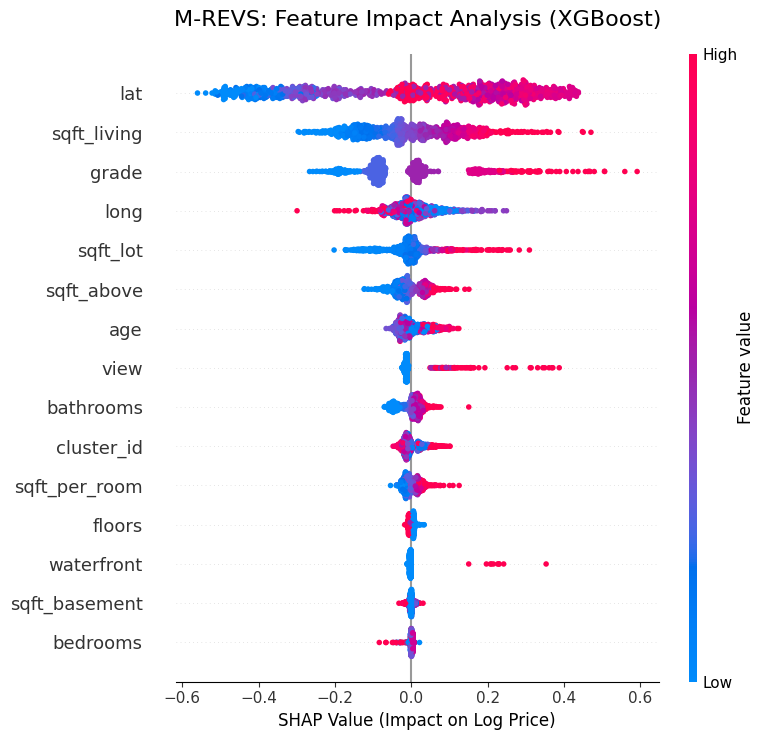

In [11]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("  Generating SHAP Explainability Report...")

try:
    if hasattr(scaler_cont, 'feature_names_in_'):
        feat_cont = list(scaler_cont.feature_names_in_)
    else:
        
        feat_cont = cont_cols 
except:
    
    feat_cont = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 
                 'sqft_living15', 'sqft_lot15', 'age', 'sqft_per_room']


feat_coord = ['lat', 'long']
feat_cluster = ['cluster_id']
feature_names = feat_cont + feat_coord + feat_cluster

print(f"    -> Mapped {len(feature_names)} feature names.")

explainer = shap.TreeExplainer(xgb_model)

sample_idx = np.random.choice(X_train_xgb.shape[0], 1000, replace=False)
X_sample = X_train_xgb[sample_idx]

shap_values = explainer.shap_values(X_sample)

print("    -> SHAP values calculated successfully.")

plt.figure(figsize=(10, 8))

# Create The "Bee Swarm" Plot

shap.summary_plot(
    shap_values, 
    X_sample, 
    feature_names=feature_names, 
    show=False,    
    plot_type="dot"
)

plt.title("M-REVS: Feature Impact Analysis (XGBoost)", fontsize=16, pad=20)
plt.xlabel("SHAP Value (Impact on Log Price)", fontsize=12)

plt.tight_layout()
plt.savefig("Analysis_SHAP_Importance.png", dpi=300, bbox_inches='tight')

print(" Success. Saved plot to 'Analysis_SHAP_Importance.png'")
plt.show()